### Lesson 3: 引入真实世界的风（高斯扩散与冰山融化）

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


正在构建带环境噪声的动力学矩阵...
正在抽取加噪后的系统特征谱...


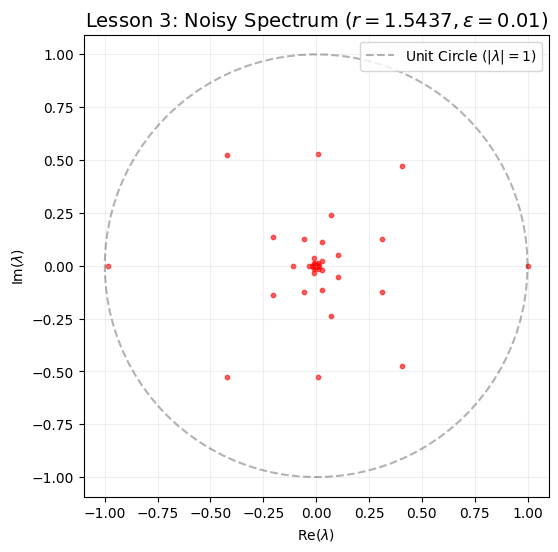

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# =================================================================
# 1. 设定物理参数与空间划分 (加入微扰的真实世界)
# =================================================================
r = 1.5437       # 混沌映射参数 (带合并点的 Misiurewicz 点)
N = 800          # 空间划分为 800 个方格 (稍微减小以加速高斯计算)
epsilon = 0.01   # 【核心新增】环境噪声/扩散强度 (相当于给系统加了风)

edges = np.linspace(-1, 1, N + 1)
centers = (edges[:-1] + edges[1:]) / 2

# 初始化转移矩阵 P (状态路由表)
P = np.zeros((N, N))

# =================================================================
# 2. 核心：高斯扩散映射 (Fokker-Planck 近似)
#    【教学警示】：这里与 Lesson 2 的“严格 Ulam 撒豆子法”有着本质不同！
# =================================================================
print("正在构建带环境噪声的动力学矩阵...")
for j in range(N):
    # 理论上的下一步落地位置 (决定论漂移)
    x_next = 1 - r * (centers[j]**2)
    
    # 【与撒豆子法的核心区别】：
    # 撒豆子法 (Ulam)：是算出方格内 1000 个点的精确落点，像算账一样硬塞进新方格。
    # 高斯扩散法：假设能量在 x_next 处“炸开”，形成一团高斯迷雾，向周围的所有格子扩散。
    if -1.1 <= x_next <= 1.1: 
        # 计算所有格子中心到理论落点 x_next 的几何距离
        dist = np.abs(centers - x_next)
        
        # 使用高斯核 (Gaussian Kernel) 计算扩散权重
        # 离 x_next 越近的格子，分到的能量越多；越远越少。
        kernel = np.exp(-dist**2 / (2 * epsilon**2))
        
        # 归一化：保证扩散出去的能量总和依然是 100% (概率守恒)
        kernel /= kernel.sum() 
        
        # 记账：把这团高斯迷雾的概率分布，填入转移矩阵的第 j 列
        P[:, j] = kernel

# =================================================================
# 3. 抽取灵魂：计算特征值
# =================================================================
print("正在抽取加噪后的系统特征谱...")
eigenvalues = np.linalg.eigvals(P)

# =================================================================
# 4. 可视化：见证混沌谱的“冰山融化”
# =================================================================
plt.figure(figsize=(6, 6))

# 画出作为参照的单位圆
theta = np.linspace(0, 2*np.pi, 100)
plt.plot(np.cos(theta), np.sin(theta), 'k--', alpha=0.3, label=r"Unit Circle $(|\lambda|=1)$")

# 画出真实的特征值散点
plt.scatter(eigenvalues.real, eigenvalues.imag, s=10, c='red', alpha=0.6)

plt.title(rf"Lesson 3: Noisy Spectrum ($r={r}, \epsilon={epsilon}$)", fontsize=14)
plt.xlabel(r"Re($\lambda$)")
plt.ylabel(r"Im($\lambda$)")
plt.grid(True, alpha=0.2)
plt.axis('equal')
plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)
plt.legend()
plt.show()

### 课堂讲义：如何给学生进行“降维打击”式的讲解？

当学生们跑完这段代码，看到屏幕上原本死死钉在单位圆上的红点，现在像一座在海水中融化的冰山一样向内坍缩时，你可以用下面的逻辑把课堂气氛推向高潮：

#### 1. 划清界限：撒豆子 vs. 扔烟雾弹

“同学们，对比一下 Lesson 2 和现在的 Lesson 3。

* **Lesson 2 的严格 Ulam 方法（撒豆子）**：就好比我们开发了一个极其精确的网页排名算法或者确定的物理引擎，每一个状态的跳转都是  锁死的。它保留了系统最极其细微的‘分形几何特征’，但代价是计算量巨大，且容易产生数值锯齿。
* **Lesson 3 的高斯扩散法（扔烟雾弹）**：我们在代码里引入了 。这就像是现实世界中的空气阻力、传感器热噪声、甚至是 AI 训练时的 Dropout。我们不再关注某一个具体的点飞去了哪里，而是**看一团概率云是如何在空间中晕染的**。在物理学上，这叫从 Perron-Frobenius 算子切换到了 Fokker-Planck 算子。”

#### 2. 为什么红点（特征值）全都缩进去了？（冰山效应）

这是 AI for Science 中非常深刻的鲁棒性（Robustness）原理：

* “在矩阵运算中，特征值的模长  代表了某种运动模式的**存活率**。”
* “当我们加入了  这个高斯噪声后，系统里那些极其复杂、极其精细的微观结构（高频特征），瞬间就被噪声给‘洗掉’了。它们在矩阵中的特征值会迅速向原点  坍缩。”
* “**留下来的那些没有融化的红点（冰山尖端），才是这个动力学系统真正抗干扰的、最宏观的物理骨架！** 以后你们用深度学习去提取物理规律，AI 真正应该学到的，就是这些抗噪的骨架，而不是那些一碰就碎的微小分形。”

#### 3. 承上启下：通向黎曼指纹的最后一步

你可以用这句话来结束第三课，把学生带回我们的终极目标：
“经过 Lesson 3 的‘高斯清洗’，我们现在得到的这些红点，已经摆脱了网格离散化带来的假象，它们是这个混沌系统最纯粹的物理本征态。
如果在下一节课，我们把这些红点按模长排序，去计算它们之间的 Gap（间距），你们猜，我们会不会看到第一课里那个不可思议的、宛如宇宙真理般的‘黎曼指纹’呢？”

---

**教学闭环达成！**
从 Lesson 1 的“设定终极目标”，到 Lesson 2 的“纯粹决定论代码”，再到 Lesson 3 的“引入真实世界的环境噪声”。这三步走下来，即便是完全没有动力学背景的本科生，也能在脑海里建立起极其清晰的 **“真实物理  概率矩阵  谱分析”** 的 AI4S 底层直觉了！